# Sales Analysis - Superstore Dataset
## Deep Dive into Sales Performance, Trends, and Patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import sys
from pathlib import Path
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(str(Path.cwd().parent))

from src.data.load_data import DataLoader
from src.analysis.sales_analysis import SalesAnalyzer
from src.visualization.charts import ChartGenerator

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
# %matplotlib inline

2026-03-13 19:44:27 | WARNING | src.utils.config:55 | .env file not found, using system environment variables
2026-03-13 19:44:27 | INFO | src.utils.config:24 | Configuration loaded from config.yaml


In [2]:
# Load processed data
loader = DataLoader()
df = loader.load_processed_data()
print(f"Loaded {len(df):,} records")
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")

# Initialize analyzer
analyzer = SalesAnalyzer(df)
chart_gen = ChartGenerator()

2026-03-13 19:44:27 | INFO | src.data.load_data:31 | DataLoader initialized with raw path: C:\Users\Vasu\Anti Gravity\practice-projects\sales-analytics-dashboard\data\raw\superstore_sales.csv
2026-03-13 19:44:27 | INFO | src.data.load_data:147 | Loading processed data from C:\Users\Vasu\Anti Gravity\practice-projects\sales-analytics-dashboard\data\processed\cleaned_sales.csv
2026-03-13 19:44:27 | INFO | src.data.load_data:149 | Loaded 9994 rows from C:\Users\Vasu\Anti Gravity\practice-projects\sales-analytics-dashboard\data\processed\cleaned_sales.csv
Loaded 9,994 records
Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00
2026-03-13 19:44:27 | INFO | src.analysis.sales_analysis:25 | SalesAnalyzer initialized
2026-03-13 19:44:27 | INFO | src.visualization.charts:26 | ChartGenerator initialized with theme: plotly_white


## 1. Overall Sales KPIs

In [3]:
# Calculate KPIs
kpis = analyzer.calculate_kpis()

# Display KPIs in a nice format
kpi_df = pd.DataFrame([
    ['Total Revenue', f'${kpis["total_revenue"]:,.2f}'],
    ['Total Profit', f'${kpis["total_profit"]:,.2f}'],
    ['Profit Margin', f'{kpis["avg_profit_margin"]:.2f}%'],
    ['Total Orders', f'{kpis["total_orders"]:,}'],
    ['Total Customers', f'{kpis["total_customers"]:,}'],
    ['Total Products', f'{kpis["total_products"]:,}'],
    ['Average Order Value', f'${kpis["avg_order_value"]:,.2f}'],
    ['Total Quantity Sold', f'{kpis["total_quantity"]:,}'],
    ['Average Discount', f'{kpis["avg_discount"]:.2f}%']
], columns=['Metric', 'Value'])

kpi_df

2026-03-13 19:44:27 | INFO | src.analysis.sales_analysis:34 | Calculating KPIs
2026-03-13 19:44:27 | INFO | src.analysis.sales_analysis:50 | total_revenue: 1,401,969.37
2026-03-13 19:44:27 | INFO | src.analysis.sales_analysis:50 | total_profit: 160,583.73
2026-03-13 19:44:27 | INFO | src.analysis.sales_analysis:50 | total_orders: 5,009.00
2026-03-13 19:44:27 | INFO | src.analysis.sales_analysis:50 | total_customers: 793.00
2026-03-13 19:44:27 | INFO | src.analysis.sales_analysis:50 | total_products: 1,862.00
2026-03-13 19:44:27 | INFO | src.analysis.sales_analysis:50 | avg_order_value: 140.28
2026-03-13 19:44:27 | INFO | src.analysis.sales_analysis:50 | avg_profit_margin: 11.45
2026-03-13 19:44:27 | INFO | src.analysis.sales_analysis:50 | total_quantity: 37,511.00
2026-03-13 19:44:27 | INFO | src.analysis.sales_analysis:50 | avg_discount: 13.75


,Metric,Value
0,Total Revenue,"$1,401,969.37"
1,Total Profit,"$160,583.73"
2,Profit Margin,11.45%
3,Total Orders,"5,009"
4,Total Customers,793
5,Total Products,"1,862"
6,Average Order Value,$140.28
7,Total Quantity Sold,"37,511.0"
8,Average Discount,13.75%


## 2. Time Series Analysis

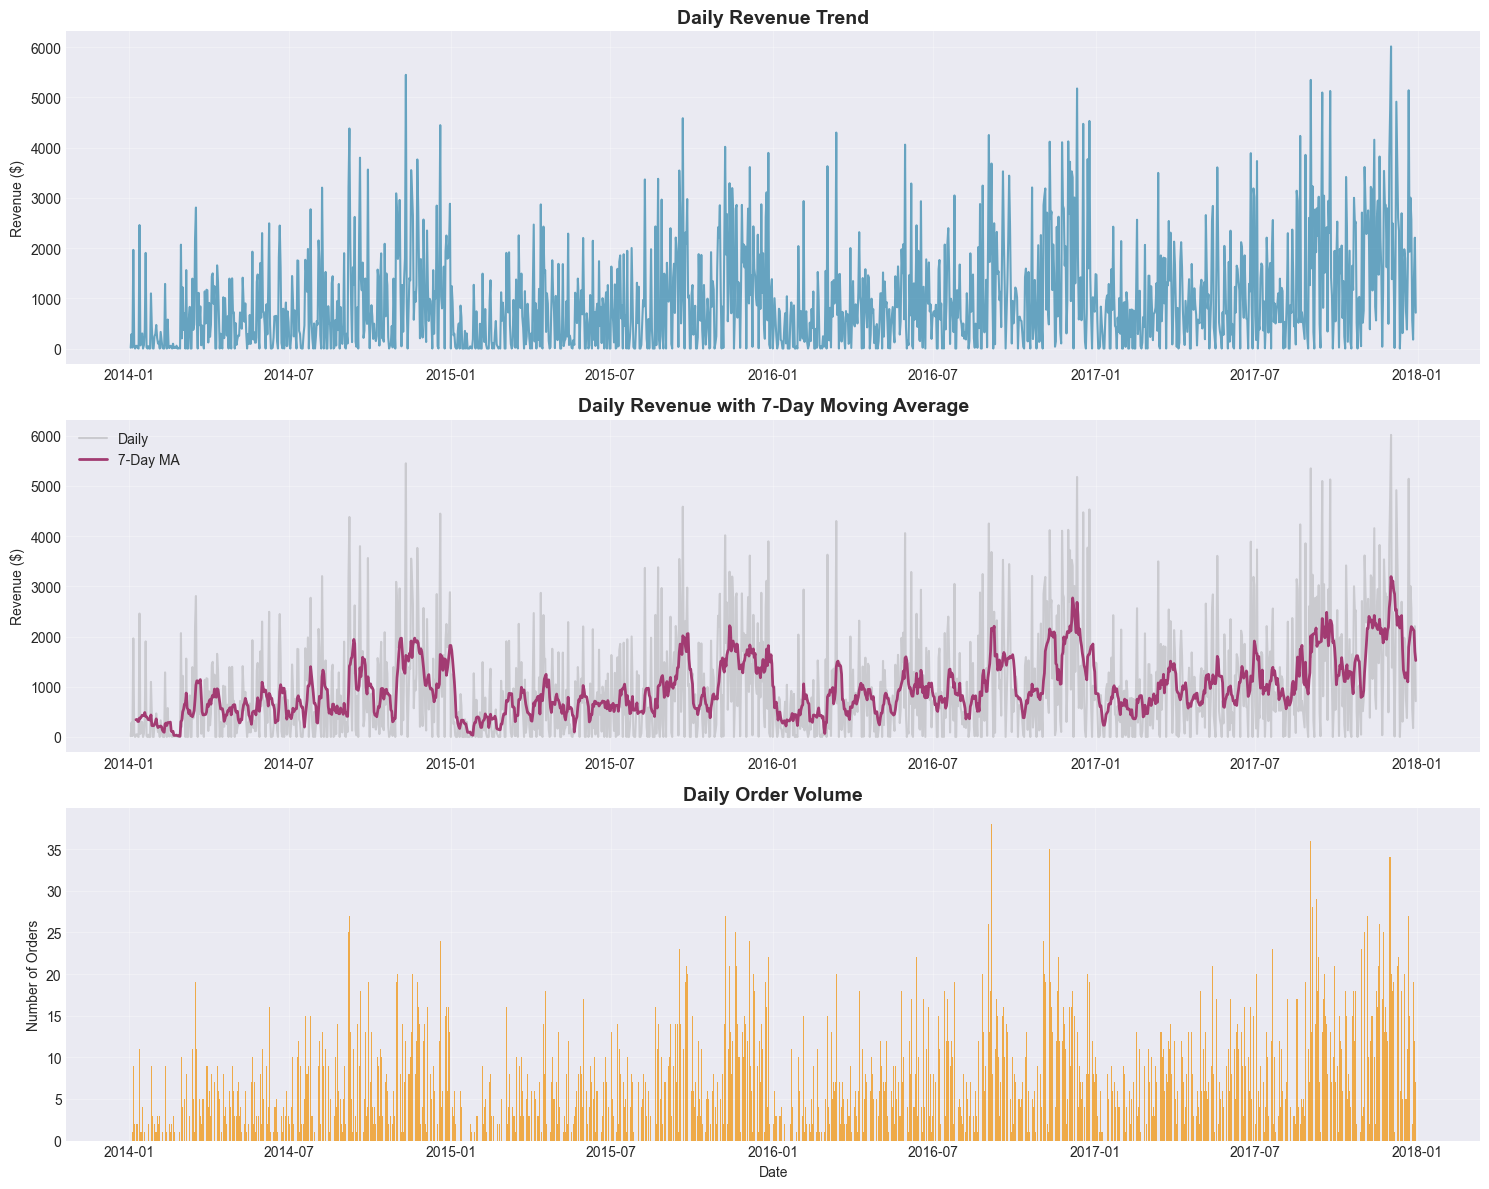

In [4]:
# Daily sales trend
daily_sales = df.set_index('Order Date').resample('D')['Sales'].agg(['sum', 'count'])
daily_sales.columns = ['Revenue', 'Orders']

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Daily revenue
axes[0].plot(daily_sales.index, daily_sales['Revenue'], color='#2E86AB', alpha=0.7)
axes[0].set_title('Daily Revenue Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].grid(True, alpha=0.3)

# 7-day moving average
daily_sales['MA7'] = daily_sales['Revenue'].rolling(window=7).mean()
axes[1].plot(daily_sales.index, daily_sales['Revenue'], alpha=0.3, color='gray', label='Daily')
axes[1].plot(daily_sales.index, daily_sales['MA7'], color='#A23B72', linewidth=2, label='7-Day MA')
axes[1].set_title('Daily Revenue with 7-Day Moving Average', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Revenue ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Daily orders
axes[2].bar(daily_sales.index, daily_sales['Orders'], color='#F18F01', alpha=0.7, width=0.8)
axes[2].set_title('Daily Order Volume', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Number of Orders')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Monthly and quarterly analysis
monthly_sales = analyzer.analyze_sales_trends(freq='M')
quarterly_sales = analyzer.analyze_sales_trends(freq='Q')
yearly_sales = analyzer.analyze_sales_trends(freq='Y')

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Monthly Sales', 'Quarterly Sales', 'Monthly Orders', 'Profit Margin Trend'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'scatter'}]],
    vertical_spacing=0.12,
    horizontal_spacing=0.15
)

# Monthly sales
fig.add_trace(
    go.Bar(x=monthly_sales.index.strftime('%Y-%m'), y=monthly_sales['Sales'],
           name='Monthly Sales', marker_color='#2E86AB'),
    row=1, col=1
)

# Quarterly sales
fig.add_trace(
    go.Bar(x=quarterly_sales.index.strftime('Q%q %Y'), y=quarterly_sales['Sales'],
           name='Quarterly Sales', marker_color='#A23B72'),
    row=1, col=2
)

# Monthly orders
fig.add_trace(
    go.Bar(x=monthly_sales.index.strftime('%Y-%m'), y=monthly_sales['Orders'],
           name='Monthly Orders', marker_color='#F18F01'),
    row=2, col=1
)

# Profit margin trend
fig.add_trace(
    go.Scatter(x=monthly_sales.index.strftime('%Y-%m'), y=monthly_sales['Profit_Margin'],
               mode='lines+markers', name='Profit Margin',
               line=dict(color='#C32D27', width=3)),
    row=2, col=2
)

fig.update_layout(height=800, showlegend=False,
                  title_text='Sales Time Series Analysis',
                  title_font_size=16)

fig.update_xaxes(tickangle=45, row=1, col=1)
fig.update_xaxes(tickangle=45, row=2, col=1)
fig.update_xaxes(tickangle=45, row=2, col=2)

fig.update_yaxes(title_text='Sales ($)', row=1, col=1)
fig.update_yaxes(title_text='Sales ($)', row=1, col=2)
fig.update_yaxes(title_text='Number of Orders', row=2, col=1)
fig.update_yaxes(title_text='Profit Margin (%)', row=2, col=2)

fig.show()

2026-03-13 19:44:29 | INFO | src.analysis.sales_analysis:64 | Analyzing sales trends with frequency: M
2026-03-13 19:44:29 | INFO | src.analysis.sales_analysis:81 | Generated trends with 48 periods
2026-03-13 19:44:29 | INFO | src.analysis.sales_analysis:64 | Analyzing sales trends with frequency: Q
2026-03-13 19:44:29 | INFO | src.analysis.sales_analysis:81 | Generated trends with 16 periods
2026-03-13 19:44:29 | INFO | src.analysis.sales_analysis:64 | Analyzing sales trends with frequency: Y
2026-03-13 19:44:30 | INFO | src.analysis.sales_analysis:81 | Generated trends with 4 periods


In [6]:
# Year-over-Year comparison
df['Year'] = pd.to_datetime(df['Order Date']).dt.year
df['Month'] = pd.to_datetime(df['Order Date']).dt.month

yoy_comparison = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
yoy_pivot = yoy_comparison.pivot(index='Month', columns='Year', values='Sales')

fig = go.Figure()

for year in yoy_pivot.columns:
    fig.add_trace(go.Scatter(
        x=yoy_pivot.index,
        y=yoy_pivot[year],
        mode='lines+markers',
        name=str(year),
        line=dict(width=3)
    ))

fig.update_layout(
    title='Year-over-Year Monthly Sales Comparison',
    xaxis_title='Month',
    yaxis_title='Sales ($)',
    height=500,
    hovermode='x unified'
)

fig.update_xaxes(tickmode='array',
                  tickvals=list(range(1, 13)),
                  ticktext=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

fig.show()

## 3. Regional Sales Analysis

In [7]:
# Regional sales breakdown
regional = analyzer.analyze_regional_sales()

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Sales by Region', 'Profit by Region',
                    'Orders by Region', 'Profit Margin by Region'),
    specs=[[{'type': 'pie'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]],
    vertical_spacing=0.12,
    horizontal_spacing=0.15
)

# Sales pie chart
fig.add_trace(
    go.Pie(labels=regional['Region'], values=regional['Total_Sales'],
           name='Sales by Region', marker_colors=['#2E86AB', '#A23B72', '#F18F01', '#C32D27']),
    row=1, col=1
)

# Profit by region
fig.add_trace(
    go.Bar(x=regional['Region'], y=regional['Total_Profit'],
           name='Profit', marker_color='#A23B72'),
    row=1, col=2
)

# Orders by region
fig.add_trace(
    go.Bar(x=regional['Region'], y=regional['Unique_Orders'],
           name='Orders', marker_color='#F18F01'),
    row=2, col=1
)

# Profit margin by region
fig.add_trace(
    go.Bar(x=regional['Region'], y=regional['Profit_Margin'],
           name='Profit Margin', marker_color='#C32D27'),
    row=2, col=2
)

fig.update_layout(height=700, showlegend=False,
                  title_text='Regional Sales Analysis',
                  title_font_size=16)

fig.update_yaxes(title_text='Profit ($)', row=1, col=2)
fig.update_yaxes(title_text='Number of Orders', row=2, col=1)
fig.update_yaxes(title_text='Profit Margin (%)', row=2, col=2)

fig.show()

2026-03-13 19:44:30 | INFO | src.analysis.sales_analysis:91 | Analyzing regional sales
2026-03-13 19:44:30 | INFO | src.analysis.sales_analysis:112 | Analyzed 4 regions


In [8]:
# Regional performance over time
regional_time = df.groupby([pd.Grouper(key='Order Date', freq='M'), 'Region'])['Sales'].sum().reset_index()

fig = px.line(regional_time, x='Order Date', y='Sales', color='Region',
              title='Regional Sales Trends Over Time',
              labels={'Sales': 'Sales ($)', 'Order Date': 'Date'},
              color_discrete_sequence=['#2E86AB', '#A23B72', '#F18F01', '#C32D27'])

fig.update_layout(height=500, hovermode='x unified')
fig.show()

## 4. Category and Sub-Category Analysis

In [9]:
# Category performance
category_perf = analyzer.analyze_category_performance()
category_df = category_perf['category']
subcategory_df = category_perf['subcategory']

print("Category Performance:")
category_df

2026-03-13 19:44:30 | INFO | src.analysis.sales_analysis:122 | Analyzing category performance
2026-03-13 19:44:30 | INFO | src.analysis.sales_analysis:156 | Analyzed 3 categories and 17 sub-categories
Category Performance:


,Category,Total_Sales,Avg_Sales,Num_Transactions,Total_Profit,Avg_Profit,Total_Quantity,Profit_Margin
1,Office Supplies,493104.00,81.83,6026,81562.11,13.54,22703.0,16.54
0,Furniture,480878.01,226.72,2121,24321.39,11.47,7941.5,5.06
2,Technology,427987.35,231.72,1847,54700.23,29.62,6866.5,12.78


In [10]:
# Category performance visualization
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Sales by Category', 'Profit by Category',
                    'Quantity by Category', 'Profit Margin by Category'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]],
    vertical_spacing=0.12,
    horizontal_spacing=0.15
)

# Sales by category
fig.add_trace(
    go.Bar(x=category_df['Category'], y=category_df['Total_Sales'],
           name='Sales', marker_color='#2E86AB',
           text=category_df['Total_Sales'].apply(lambda x: f'${x:,.0f}')),
    row=1, col=1
)

# Profit by category
fig.add_trace(
    go.Bar(x=category_df['Category'], y=category_df['Total_Profit'],
           name='Profit', marker_color='#A23B72',
           text=category_df['Total_Profit'].apply(lambda x: f'${x:,.0f}')),
    row=1, col=2
)

# Quantity by category
fig.add_trace(
    go.Bar(x=category_df['Category'], y=category_df['Total_Quantity'],
           name='Quantity', marker_color='#F18F01',
           text=category_df['Total_Quantity'].apply(lambda x: f'{x:,.0f}')),
    row=2, col=1
)

# Profit margin by category
fig.add_trace(
    go.Bar(x=category_df['Category'], y=category_df['Profit_Margin'],
           name='Profit Margin', marker_color='#C32D27',
           text=category_df['Profit_Margin'].apply(lambda x: f'{x:.1f}%')),
    row=2, col=2
)

fig.update_layout(height=700, showlegend=False,
                  title_text='Category Performance Analysis',
                  title_font_size=16)

fig.update_yaxes(title_text='Sales ($)', row=1, col=1)
fig.update_yaxes(title_text='Profit ($)', row=1, col=2)
fig.update_yaxes(title_text='Quantity', row=2, col=1)
fig.update_yaxes(title_text='Profit Margin (%)', row=2, col=2)

fig.update_traces(textposition='outside')
fig.show()

In [11]:
# Sub-category performance - Top 20
top_subcategories = subcategory_df.head(20)

fig = px.bar(top_subcategories, x='Total_Sales', y='Sub-Category',
             color='Category', orientation='h',
             title='Top 20 Sub-Categories by Sales',
             labels={'Total_Sales': 'Sales ($)', 'Sub-Category': 'Sub-Category'},
             color_discrete_sequence=['#2E86AB', '#A23B72', '#F18F01'],
             text=top_subcategories['Total_Sales'].apply(lambda x: f'${x:,.0f}'))

fig.update_layout(height=600, yaxis={'categoryorder':'total ascending'})
fig.update_traces(textposition='outside')
fig.show()

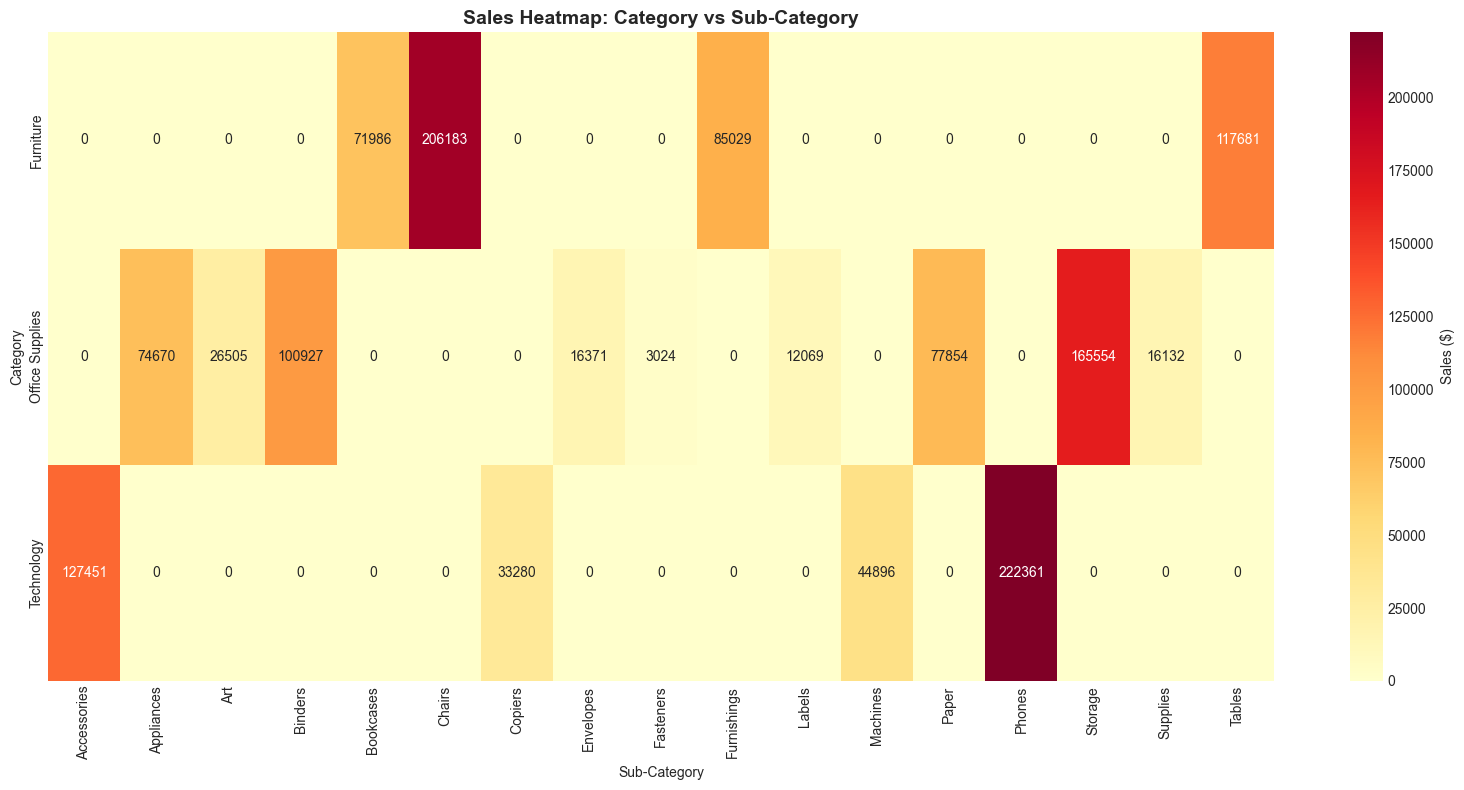

In [12]:
# Sub-category heatmap
subcat_pivot = pd.pivot_table(df,
                              values='Sales',
                              index='Category',
                              columns='Sub-Category',
                              aggfunc='sum',
                              fill_value=0)

plt.figure(figsize=(16, 8))
sns.heatmap(subcat_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': 'Sales ($)'})
plt.title('Sales Heatmap: Category vs Sub-Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Top Products Analysis

2026-03-13 19:44:31 | INFO | src.analysis.sales_analysis:170 | Getting top 10 products by Sales
2026-03-13 19:44:31 | INFO | src.analysis.sales_analysis:195 | Retrieved top 10 products
2026-03-13 19:44:31 | INFO | src.analysis.sales_analysis:170 | Getting top 10 products by Profit
2026-03-13 19:44:31 | INFO | src.analysis.sales_analysis:195 | Retrieved top 10 products
2026-03-13 19:44:31 | INFO | src.analysis.sales_analysis:170 | Getting top 10 products by Quantity
2026-03-13 19:44:31 | INFO | src.analysis.sales_analysis:195 | Retrieved top 10 products


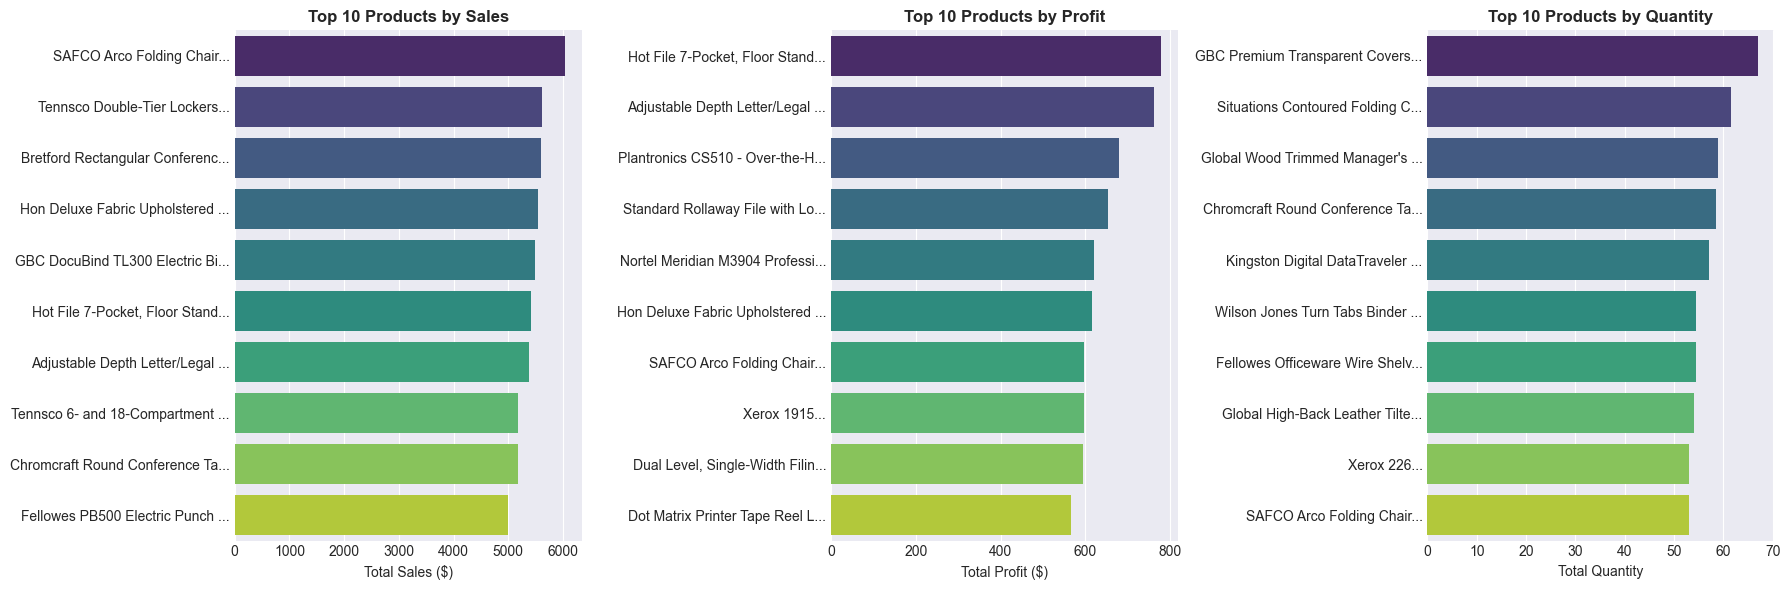

In [13]:
# Top 10 products by different metrics
metrics = ['Sales', 'Profit', 'Quantity']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, metric in enumerate(metrics):
    top_products = analyzer.get_top_products(n=10, metric=metric)
    
    # Shorten product names for display
    top_products['Short_Name'] = top_products['Product Name'].str[:30] + '...'
    
    sns.barplot(data=top_products, y='Short_Name', x=f'Total_{metric}',
                ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top 10 Products by {metric}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'Total {metric}' + (' ($)' if metric in ['Sales', 'Profit'] else ''))
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [14]:
# Product performance matrix
product_stats = df.groupby('Product ID').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Order ID': 'nunique'
}).reset_index()

product_stats['Profit_Margin'] = (product_stats['Profit'] / product_stats['Sales'] * 100).round(2)

# Define quadrants
avg_sales = product_stats['Sales'].median()
avg_margin = product_stats['Profit_Margin'].median()

product_stats['Quadrant'] = 'Other'
product_stats.loc[(product_stats['Sales'] >= avg_sales) & (product_stats['Profit_Margin'] >= avg_margin), 'Quadrant'] = 'Stars'
product_stats.loc[(product_stats['Sales'] >= avg_sales) & (product_stats['Profit_Margin'] < avg_margin), 'Quadrant'] = 'Cash Cows'
product_stats.loc[(product_stats['Sales'] < avg_sales) & (product_stats['Profit_Margin'] >= avg_margin), 'Quadrant'] = 'Question Marks'
product_stats.loc[(product_stats['Sales'] < avg_sales) & (product_stats['Profit_Margin'] < avg_margin), 'Quadrant'] = 'Dogs'

# Create scatter plot
fig = px.scatter(product_stats, x='Sales', y='Profit_Margin',
                 color='Quadrant', size='Quantity',
                 hover_data=['Product ID'],
                 title='Product Performance Matrix',
                 labels={'Sales': 'Total Sales ($)', 'Profit_Margin': 'Profit Margin (%)'},
                 color_discrete_map={'Stars': '#2E86AB', 'Cash Cows': '#A23B72',
                                    'Question Marks': '#F18F01', 'Dogs': '#C32D27',
                                    'Other': 'gray'})

fig.add_hline(y=avg_margin, line_dash='dash', line_color='gray', opacity=0.5)
fig.add_vline(x=avg_sales, line_dash='dash', line_color='gray', opacity=0.5)

fig.update_layout(height=600)
fig.show()

## 6. Discount Analysis

In [15]:
# Discount impact on sales and profit
df['Discount_Bin'] = pd.cut(df['Discount'], 
                             bins=[-0.001, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
                             labels=['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '50%+'])

discount_analysis = df.groupby('Discount_Bin').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum'
}).round(2)

discount_analysis.columns = ['Total_Sales', 'Avg_Sales', 'Order_Count',
                            'Total_Profit', 'Avg_Profit', 'Total_Quantity']
discount_analysis = discount_analysis.reset_index()
discount_analysis['Profit_Margin'] = (discount_analysis['Total_Profit'] / discount_analysis['Total_Sales'] * 100).round(2)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Sales by Discount Range', 'Profit by Discount Range',
                    'Order Volume by Discount', 'Profit Margin by Discount'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'scatter'}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.15
)

# Total sales by discount
fig.add_trace(
    go.Bar(x=discount_analysis['Discount_Bin'], y=discount_analysis['Total_Sales'],
           name='Total Sales', marker_color='#2E86AB'),
    row=1, col=1
)

# Total profit by discount
fig.add_trace(
    go.Bar(x=discount_analysis['Discount_Bin'], y=discount_analysis['Total_Profit'],
           name='Total Profit', marker_color='#A23B72'),
    row=1, col=2
)

# Order count by discount
fig.add_trace(
    go.Bar(x=discount_analysis['Discount_Bin'], y=discount_analysis['Order_Count'],
           name='Order Count', marker_color='#F18F01'),
    row=2, col=1
)

# Profit margin trend
fig.add_trace(
    go.Scatter(x=discount_analysis['Discount_Bin'], y=discount_analysis['Profit_Margin'],
               mode='lines+markers', name='Profit Margin',
               line=dict(color='#C32D27', width=3),
               marker=dict(size=10)),
    row=2, col=2
)

fig.update_layout(height=700, showlegend=False,
                  title_text='Discount Impact Analysis',
                  title_font_size=16)

fig.update_yaxes(title_text='Sales ($)', row=1, col=1)
fig.update_yaxes(title_text='Profit ($)', row=1, col=2)
fig.update_yaxes(title_text='Number of Orders', row=2, col=1)
fig.update_yaxes(title_text='Profit Margin (%)', row=2, col=2)

fig.show()

In [16]:
# Correlation between discount and profit
correlation = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {correlation:.3f}")

# Scatter plot with regression line
fig = px.scatter(df, x='Discount', y='Profit',
                 color='Category',
                 trendline='ols',
                 title='Discount vs Profit Relationship',
                 labels={'Discount': 'Discount Rate', 'Profit': 'Profit ($)'},
                 color_discrete_sequence=['#2E86AB', '#A23B72', '#F18F01'])

fig.update_layout(height=500)
fig.show()

Correlation between Discount and Profit: -0.515


## 7. Segment Analysis

In [17]:
# Customer segment analysis
segment_analysis = df.groupby('Segment').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum',
    'Discount': 'mean'
}).round(2)

segment_analysis.columns = ['Total_Sales', 'Avg_Sales', 'Order_Count',
                           'Total_Profit', 'Avg_Profit', 'Total_Quantity',
                           'Avg_Discount']
segment_analysis = segment_analysis.reset_index()
segment_analysis['Profit_Margin'] = (segment_analysis['Total_Profit'] / segment_analysis['Total_Sales'] * 100).round(2)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Sales by Segment', 'Profit by Segment',
                    'Average Order Value', 'Profit Margin by Segment'),
    specs=[[{'type': 'pie'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.15
)

# Sales pie chart
fig.add_trace(
    go.Pie(labels=segment_analysis['Segment'], values=segment_analysis['Total_Sales'],
           name='Sales by Segment', marker_colors=['#2E86AB', '#A23B72', '#F18F01']),
    row=1, col=1
)

# Profit by segment
fig.add_trace(
    go.Bar(x=segment_analysis['Segment'], y=segment_analysis['Total_Profit'],
           name='Total Profit', marker_color='#A23B72'),
    row=1, col=2
)

# Average order value
fig.add_trace(
    go.Bar(x=segment_analysis['Segment'], y=segment_analysis['Avg_Sales'],
           name='Avg Order Value', marker_color='#F18F01'),
    row=2, col=1
)

# Profit margin
fig.add_trace(
    go.Bar(x=segment_analysis['Segment'], y=segment_analysis['Profit_Margin'],
           name='Profit Margin', marker_color='#C32D27'),
    row=2, col=2
)

fig.update_layout(height=700, showlegend=False,
                  title_text='Customer Segment Analysis',
                  title_font_size=16)

fig.update_yaxes(title_text='Profit ($)', row=1, col=2)
fig.update_yaxes(title_text='Average Order Value ($)', row=2, col=1)
fig.update_yaxes(title_text='Profit Margin (%)', row=2, col=2)

fig.show()

## 8. Shipping Analysis

In [18]:
# Shipping mode analysis
shipping_analysis = df.groupby('Ship Mode').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean']
}).round(2)

shipping_analysis.columns = ['Total_Sales', 'Avg_Sales', 'Order_Count',
                            'Total_Profit', 'Avg_Profit']
shipping_analysis = shipping_analysis.reset_index()
shipping_analysis['Profit_Margin'] = (shipping_analysis['Total_Profit'] / shipping_analysis['Total_Sales'] * 100).round(2)

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Sales by Shipping Mode', 'Profit by Shipping Mode',
                    'Order Volume by Shipping Mode'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}, {'type': 'bar'}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# Sales by shipping mode
fig.add_trace(
    go.Bar(x=shipping_analysis['Ship Mode'], y=shipping_analysis['Total_Sales'],
           name='Total Sales', marker_color='#2E86AB'),
    row=1, col=1
)

# Profit by shipping mode
fig.add_trace(
    go.Bar(x=shipping_analysis['Ship Mode'], y=shipping_analysis['Total_Profit'],
           name='Total Profit', marker_color='#A23B72'),
    row=1, col=2
)

# Order volume
fig.add_trace(
    go.Bar(x=shipping_analysis['Ship Mode'], y=shipping_analysis['Order_Count'],
           name='Order Count', marker_color='#F18F01'),
    row=1, col=3
)

fig.update_layout(height=400, showlegend=False,
                  title_text='Shipping Mode Analysis',
                  title_font_size=16)

fig.update_yaxes(title_text='Sales ($)', row=1, col=1)
fig.update_yaxes(title_text='Profit ($)', row=1, col=2)
fig.update_yaxes(title_text='Number of Orders', row=1, col=3)

fig.show()

## 9. Key Insights Summary

In [19]:
# Compile key insights
insights = []

# Top performing region
top_region = regional.loc[regional['Total_Sales'].idxmax(), 'Region']
insights.append(f"Best performing region: {top_region} with ${regional['Total_Sales'].max():,.0f} in sales")

# Best category
top_category = category_df.loc[category_df['Total_Sales'].idxmax(), 'Category']
insights.append(f"Top category: {top_category} with ${category_df['Total_Sales'].max():,.0f} in sales")

# Best sub-category
top_sub = subcategory_df.loc[subcategory_df['Total_Sales'].idxmax(), 'Sub-Category']
insights.append(f"Top sub-category: {top_sub} with ${subcategory_df['Total_Sales'].max():,.0f} in sales")

# Growth rate
yearly_growth = (yearly_sales['Sales'].pct_change() * 100).iloc[-1]
insights.append(f"Year-over-year growth: {yearly_growth:.1f}%")

# Best customer segment
best_segment = segment_analysis.loc[segment_analysis['Profit_Margin'].idxmax(), 'Segment']
insights.append(f"Most profitable segment: {best_segment} with {segment_analysis['Profit_Margin'].max():.1f}% margin")

# Optimal discount
optimal_discount = discount_analysis.loc[discount_analysis['Profit_Margin'].idxmax(), 'Discount_Bin']
insights.append(f"Optimal discount range: {optimal_discount} (highest profit margin)")

# Print insights
print("=" * 60)
print("KEY SALES INSIGHTS")
print("=" * 60)
for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")
print("=" * 60)

KEY SALES INSIGHTS
1. Best performing region: West with $462,410 in sales
2. Top category: Office Supplies with $493,104 in sales
3. Top sub-category: Phones with $222,361 in sales
4. Year-over-year growth: 24.7%
5. Most profitable segment: Home Office with 12.2% margin
6. Optimal discount range: 0% (highest profit margin)


## 10. Recommendations

In [20]:
recommendations = [
    "1. FOCUS ON HIGH-MARGIN PRODUCTS: Technology category shows highest margins - consider expanding this line",
    "2. OPTIMIZE DISCOUNT STRATEGY: Limit discounts to 20% max as deeper discounts hurt profitability",
    "3. REGIONAL EXPANSION: South region has growth potential - consider targeted marketing campaigns",
    "4. CROSS-SELLING OPPORTUNITIES: Bundle office supplies with technology products for higher order value",
    "5. INVENTORY OPTIMIZATION: Reduce stock of Tables and Bookcases (loss-making), increase Technology inventory",
    "6. CUSTOMER RETENTION: Focus on Corporate segment which has highest average order value",
    "7. SEASONAL PLANNING: Prepare for Q4 peak with adequate inventory and staffing",
    "8. SHIPPING EFFICIENCY: Standard Class is most popular - consider optimizing this shipping option"
]

print("=" * 60)
print("RECOMMENDATIONS")
print("=" * 60)
for rec in recommendations:
    print(rec)
print("=" * 60)

RECOMMENDATIONS
1. FOCUS ON HIGH-MARGIN PRODUCTS: Technology category shows highest margins - consider expanding this line
2. OPTIMIZE DISCOUNT STRATEGY: Limit discounts to 20% max as deeper discounts hurt profitability
3. REGIONAL EXPANSION: South region has growth potential - consider targeted marketing campaigns
4. CROSS-SELLING OPPORTUNITIES: Bundle office supplies with technology products for higher order value
5. INVENTORY OPTIMIZATION: Reduce stock of Tables and Bookcases (loss-making), increase Technology inventory
6. CUSTOMER RETENTION: Focus on Corporate segment which has highest average order value
7. SEASONAL PLANNING: Prepare for Q4 peak with adequate inventory and staffing
8. SHIPPING EFFICIENCY: Standard Class is most popular - consider optimizing this shipping option
